# Fraud Detection Baseline Notebook

이 노트북은 train.csv 기준으로 **EDA → Feature Engineering → 모델 선정 → 학습 및 반복 개선** 순서의 baseline pipeline을 담고 있습니다.

구성:
1. 환경 설정 및 데이터 로드
2. EDA
3. Feature Engineering
4. Validation 전략
5. LightGBM Baseline 학습
6. Feature Importance 확인
7. 다음 반복 개선 아이디어


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

import lightgbm as lgb


## 1. 데이터 로드

- 파일명은 `train.csv` 기준
- 필요하면 경로를 수정해서 사용


In [2]:
TRAIN_PATH = 'csv/train.csv'

TARGET = 'fraud_bool'
ID_COL = 'id'

train = pd.read_csv(TRAIN_PATH)
print(train.shape)
train.head()


(700000, 33)


,id,fraud_bool,yearly_income,name_email_sim,prev_addr_months,curr_addr_months,age_bucket,days_since_req,init_transfer_amt,payment_type,...,has_other_cards,req_credit_limit,is_foreign_req,application_source,session_length_min,device_os,is_session_persistent,device_email_cnt_8w,device_fraud_history,month_idx
0,0,0,0.8,0.996036,9,19,40,0.019167,-0.795951,AB,...,1,510.0,0,INTERNET,4.125364,other,1,1,0,6
1,1,0,0.8,0.520470,12,10,30,0.010994,-0.667975,AD,...,0,1500.0,0,INTERNET,8.147967,macintosh,0,1,0,4
2,2,0,0.5,0.792133,162,11,40,70.144985,-1.051204,AC,...,0,200.0,0,INTERNET,4.996239,linux,1,1,0,3
3,3,0,0.1,0.846394,24,7,50,0.005721,-1.404540,AB,...,0,200.0,0,INTERNET,5.860972,linux,1,1,0,6
4,4,0,0.9,0.232846,-1,81,40,0.023110,-0.519206,AD,...,0,200.0,0,INTERNET,12.764765,windows,0,1,0,4


In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 33 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     700000 non-null  int64  
 1   fraud_bool             700000 non-null  int64  
 2   yearly_income          700000 non-null  float64
 3   name_email_sim         700000 non-null  float64
 4   prev_addr_months       700000 non-null  int64  
 5   curr_addr_months       700000 non-null  int64  
 6   age_bucket             700000 non-null  int64  
 7   days_since_req         700000 non-null  float64
 8   init_transfer_amt      700000 non-null  float64
 9   payment_type           700000 non-null  str    
 10  zip_req_count_4w       700000 non-null  int64  
 11  req_rate_6h            700000 non-null  float64
 12  req_rate_24h           700000 non-null  float64
 13  req_rate_4w            700000 non-null  float64
 14  branch_req_count_8w    700000 non-null  int64  

## 2. EDA

baseline 단계에서는 **빠르게 확인해야 하는 것** 위주로 봅니다.

- target imbalance
- numeric / categorical 구분
- 결측치 여부
- 범주형 cardinality
- 기본 통계량


In [4]:
print('Target distribution')
display(train[TARGET].value_counts())
display(train[TARGET].value_counts(normalize=True))

Target distribution


fraud_bool
0    692358
1      7642
Name: count, dtype: int64

fraud_bool
0    0.989083
1    0.010917
Name: proportion, dtype: float64

In [5]:
num_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = train.select_dtypes(include=['object']).columns.tolist()

for col in [TARGET, ID_COL]:
    if col in num_cols:
        num_cols.remove(col)

print('Numeric columns:', len(num_cols))
print(num_cols)
print('\nCategorical columns:', len(cat_cols))
print(cat_cols)

Numeric columns: 26
['yearly_income', 'name_email_sim', 'prev_addr_months', 'curr_addr_months', 'age_bucket', 'days_since_req', 'init_transfer_amt', 'zip_req_count_4w', 'req_rate_6h', 'req_rate_24h', 'req_rate_4w', 'branch_req_count_8w', 'dob_email_count_4w', 'credit_risk_score', 'is_free_email', 'is_home_phone_valid', 'is_mobile_valid', 'bank_months_count', 'has_other_cards', 'req_credit_limit', 'is_foreign_req', 'session_length_min', 'is_session_persistent', 'device_email_cnt_8w', 'device_fraud_history', 'month_idx']

Categorical columns: 5
['payment_type', 'employment_status', 'housing_status', 'application_source', 'device_os']


In [6]:
missing = train.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print('Missing columns count:', len(missing))
display(missing.head(20))


Missing columns count: 0


Series([], dtype: int64)

In [7]:
display(train[num_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
yearly_income,700000.0,0.562678,0.290138,1.000000e-01,0.300000,0.600000,0.800000,0.900000
name_email_sim,700000.0,0.493689,0.289164,2.042122e-05,0.225274,0.492128,0.755541,0.999999
prev_addr_months,700000.0,16.719490,44.049827,-1.000000e+00,-1.000000,-1.000000,12.000000,381.000000
curr_addr_months,700000.0,86.623213,88.439563,-1.000000e+00,19.000000,52.000000,130.000000,425.000000
age_bucket,700000.0,33.681886,12.025505,1.000000e+01,20.000000,30.000000,40.000000,90.000000
days_since_req,700000.0,1.026138,5.380082,4.036860e-09,0.007185,0.015178,0.026337,78.456904
init_transfer_amt,700000.0,8.683809,20.258896,-1.553055e+01,-1.180621,-0.830318,5.147847,112.452078
zip_req_count_4w,700000.0,1571.702950,1005.214140,1.000000e+00,893.000000,1261.000000,1943.000000,6700.000000
req_rate_6h,700000.0,5665.777022,3010.604652,-1.554307e+02,3437.766683,5318.280659,7678.964338,16715.565404
req_rate_24h,700000.0,4769.696098,1479.796894,1.300307e+03,3592.646596,4749.490037,5752.333251,9506.896596


In [8]:
cat_summary = pd.DataFrame({
    'nunique': train[cat_cols].nunique(),
    'sample_values': [train[col].astype(str).unique()[:5].tolist() for col in cat_cols]
})
display(cat_summary)

,nunique,sample_values
payment_type,5,"[AB, AD, AC, AA, AE]"
employment_status,7,"[CA, CB, CC, CE, CD]"
housing_status,7,"[BC, BA, BB, BE, BD]"
application_source,2,"[INTERNET, TELEAPP]"
device_os,5,"[other, macintosh, linux, windows, x11]"


## 3. Feature Engineering

baseline에서는 복잡한 target encoding보다 먼저 **안전하고 빠른 파생 변수**를 만듭니다.

아이디어:
- 단기/장기 요청 빈도 비율
- 주소 안정성
- 소득 대비 요청 한도
- 디바이스 리스크
- 세션 길이 대비 활동량


In [12]:
df = train.copy()

# 1) request rate ratio features
df['req_rate_ratio_6h_24h'] = df['req_rate_6h'] / (df['req_rate_24h'] + 1e-5)
df['req_rate_ratio_24h_4w'] = df['req_rate_24h'] / (df['req_rate_4w'] + 1e-5)

# 2) address stability
df['addr_stability'] = df['curr_addr_months'] / (df['prev_addr_months'] + 1)
df['total_addr_months'] = df['curr_addr_months'] + df['prev_addr_months']

# 3) finance-related ratios
df['credit_per_income'] = df['req_credit_limit'] / (df['yearly_income'] + 1e-5)
df['transfer_per_income'] = df['init_transfer_amt'] / (df['yearly_income'] + 1e-5)

# 4) device risk
df['device_risk'] = df['device_fraud_history'] * df['device_email_cnt_8w']

# 5) session behavior
df['session_per_req24h'] = df['session_length_min'] / (df['req_rate_24h'] + 1e-5)
df['session_per_req6h'] = df['session_length_min'] / (df['req_rate_6h'] + 1e-5)

# 6) contact validity summary
df['valid_contact_count'] = df['is_home_phone_valid'] + df['is_mobile_valid']

# 7) request pressure summary
df['request_pressure'] = (
    df['zip_req_count_4w'] +
    df['branch_req_count_8w'] +
    df['dob_email_count_4w'] +
    df['device_email_cnt_8w']
)

print(df.shape)


(700000, 44)


### 3-1. 범주형 인코딩

LightGBM은 category dtype도 다룰 수 있지만, baseline에서는 재현성과 단순성을 위해 **Label Encoding**으로 시작합니다.

나중에 비교해볼 만한 확장:
- frequency encoding
- target encoding (반드시 fold-safe)
- CatBoost 사용


In [13]:
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

df.head()

,id,fraud_bool,yearly_income,name_email_sim,prev_addr_months,curr_addr_months,age_bucket,days_since_req,init_transfer_amt,payment_type,...,req_rate_ratio_24h_4w,addr_stability,total_addr_months,credit_per_income,transfer_per_income,device_risk,session_per_req24h,session_per_req6h,valid_contact_count,request_pressure
0,0,0,0.8,0.996036,9,19,40,0.019167,-0.795951,1,...,0.942821,1.900000,28,637.492031,-0.994927,0,0.000684,0.000532,1,1284
1,1,0,0.8,0.520470,12,10,30,0.010994,-0.667975,3,...,0.587015,0.769231,22,1874.976563,-0.834958,0,0.002532,0.001942,1,3305
2,2,0,0.5,0.792133,162,11,40,70.144985,-1.051204,2,...,0.908098,0.067485,173,399.992000,-2.102365,0,0.001097,0.000559,1,513
3,3,0,0.1,0.846394,24,7,50,0.005721,-1.404540,1,...,0.847824,0.280000,31,1999.800020,-14.043993,0,0.001578,0.001256,2,6748
4,4,0,0.9,0.232846,-1,81,40,0.023110,-0.519206,3,...,0.981195,inf,80,222.219753,-0.576890,0,0.002656,0.007747,1,1443


In [14]:
FEATURES = [col for col in df.columns if col not in [TARGET, ID_COL]]
print('Number of features:', len(FEATURES))
FEATURES

Number of features: 42


['yearly_income',
 'name_email_sim',
 'prev_addr_months',
 'curr_addr_months',
 'age_bucket',
 'days_since_req',
 'init_transfer_amt',
 'payment_type',
 'zip_req_count_4w',
 'req_rate_6h',
 'req_rate_24h',
 'req_rate_4w',
 'branch_req_count_8w',
 'dob_email_count_4w',
 'employment_status',
 'credit_risk_score',
 'is_free_email',
 'housing_status',
 'is_home_phone_valid',
 'is_mobile_valid',
 'bank_months_count',
 'has_other_cards',
 'req_credit_limit',
 'is_foreign_req',
 'application_source',
 'session_length_min',
 'device_os',
 'is_session_persistent',
 'device_email_cnt_8w',
 'device_fraud_history',
 'month_idx',
 'req_rate_ratio_6h_24h',
 'req_rate_ratio_24h_4w',
 'addr_stability',
 'total_addr_months',
 'credit_per_income',
 'transfer_per_income',
 'device_risk',
 'session_per_req24h',
 'session_per_req6h',
 'valid_contact_count',
 'request_pressure']

## 4. Validation 전략

현재 baseline은 **StratifiedKFold**를 사용합니다.

주의:
- fraud 문제는 실제 서비스 환경에서 시간 누수(time leakage)에 민감할 수 있음
- `month_idx`가 있으므로 나중에는 **time-based validation**도 반드시 비교하는 것이 좋음


In [15]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X = df[FEATURES]
y = df[TARGET]

pos = y.sum()
neg = len(y) - pos
scale_pos_weight = neg / pos
print('scale_pos_weight:', scale_pos_weight)

scale_pos_weight: 90.59905783826224


## 5. LightGBM Baseline 모델

이 baseline의 장점:
- tabular 데이터에서 강함
- 빠름
- feature importance 확인 쉬움
- 반복 실험에 유리함


In [16]:
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 64,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbosity': -1,
    'random_state': 42,
    'scale_pos_weight': scale_pos_weight,
    'n_estimators': 2000
}

params

{'objective': 'binary',
 'metric': 'auc',
 'boosting_type': 'gbdt',
 'learning_rate': 0.05,
 'num_leaves': 64,
 'feature_fraction': 0.8,
 'bagging_fraction': 0.8,
 'bagging_freq': 5,
 'verbosity': -1,
 'random_state': 42,
 'scale_pos_weight': np.float64(90.59905783826224),
 'n_estimators': 2000}

In [17]:
oof_preds = np.zeros(len(df))
feature_importances = []
fold_scores = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):
    print(f'===== Fold {fold} =====')
    
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
    
    model = lgb.LGBMClassifier(**params)
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric='auc',
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(100)]
    )
    
    valid_pred = model.predict_proba(X_valid)[:, 1]
    oof_preds[valid_idx] = valid_pred
    
    fold_auc = roc_auc_score(y_valid, valid_pred)
    fold_scores.append(fold_auc)
    print(f'Fold {fold} AUC: {fold_auc:.6f}')
    
    fi = pd.DataFrame({
        'feature': FEATURES,
        'importance': model.feature_importances_,
        'fold': fold
    })
    feature_importances.append(fi)

overall_auc = roc_auc_score(y, oof_preds)
print('\n===== CV Result =====')
print('Fold AUCs:', [round(s, 6) for s in fold_scores])
print('Mean AUC:', np.mean(fold_scores))
print('OOF AUC :', overall_auc)


===== Fold 1 =====
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.881571
[200]	valid_0's auc: 0.886317
[300]	valid_0's auc: 0.886394
Early stopping, best iteration is:
[268]	valid_0's auc: 0.886463
Fold 1 AUC: 0.886463
===== Fold 2 =====
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.888026
[200]	valid_0's auc: 0.892718
[300]	valid_0's auc: 0.893037
Early stopping, best iteration is:
[235]	valid_0's auc: 0.893324
Fold 2 AUC: 0.893324
===== Fold 3 =====
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.884841
[200]	valid_0's auc: 0.889714
[300]	valid_0's auc: 0.88901
Early stopping, best iteration is:
[212]	valid_0's auc: 0.889784
Fold 3 AUC: 0.889784
===== Fold 4 =====
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.873454
[200]	valid_0's auc: 0.877932
[300]	valid_0's auc: 0.877287
Early stopping, best iteration is:
[258]	valid_0's auc: 0.8

## 6. Feature Importance

여기서 중요한 것은 단순히 높은 importance를 보는 것이 아니라:
- 어떤 파생 변수가 실제로 도움이 되었는지
- 불필요한 feature가 무엇인지
- 다음 FE iteration 방향이 어디인지

를 판단하는 것입니다.


In [9]:
fi_df = pd.concat(feature_importances, axis=0)
fi_mean = fi_df.groupby('feature')['importance'].mean().sort_values(ascending=False)
display(fi_mean.head(30).to_frame('mean_importance'))


NameError: name 'feature_importances' is not defined

## Phase 1: Advanced Feature Engineering (Phase 1-1: 심화 피처 생성 함수)

심화된 피처 엔지니어링으로 45-50개까지 피처를 확장합니다:
- Target Encoding & Frequency Encoding
- Interaction Features
- Binning & Polynomial Features  
- Time-series 특성
- Anomaly Detection Score
- Grouped Statistical Features

In [10]:
# ===== Helper Functions for Advanced FE =====
from scipy import stats
from sklearn.preprocessing import StandardScaler

def create_target_encoding_features(df_train, df_apply, categorical_cols, target_col, fold_id=None):
    """
    Fold-safe Target Encoding을 적용합니다.
    범주형 변수별 사기율(fraud_bool의 평균)을 인코딩값으로 사용합니다.
    """
    te_features = {}
    
    for col in categorical_cols:
        # Train 데이터에서 각 카테고리의 평균 사기율 계산
        te_map = df_train.groupby(col)[target_col].mean().to_dict()
        
        # 누락된 카테고리는 전체 평균으로 처리
        global_mean = df_train[target_col].mean()
        te_features[f'{col}_te'] = df_apply[col].map(te_map).fillna(global_mean)
    
    return pd.DataFrame(te_features, index=df_apply.index)

def create_frequency_encoding_features(df_train, df_apply, categorical_cols):
    """
    Frequency Encoding: 각 카테고리의 빈도수를 인코딩값으로 사용합니다.
    """
    freq_features = {}
    
    for col in categorical_cols:
        freq_map = df_train[col].value_counts(normalize=True).to_dict()
        freq_features[f'{col}_freq'] = df_apply[col].map(freq_map).fillna(0)
    
    return pd.DataFrame(freq_features, index=df_apply.index)

def create_interaction_features(df, num_cols):
    """
    수치형 컬럼 간의 상호작용 피처를 생성합니다.
    """
    interaction_features = {}
    
    # 주요 상호작용 (서로 다른 도메인의 변수들)
    interactions = [
        ('yearly_income', 'credit_risk_score'),
        ('yearly_income', 'req_credit_limit'),
        ('yearly_income', 'age_bucket'),
        ('credit_risk_score', 'device_fraud_history'),
        ('age_bucket', 'device_fraud_history'),
        ('req_rate_24h', 'req_rate_6h'),
        ('prev_addr_months', 'curr_addr_months'),
        ('is_mobile_valid', 'is_home_phone_valid'),
        ('init_transfer_amt', 'yearly_income'),
        ('dob_email_count_4w', 'device_email_cnt_8w'),
    ]
    
    for col1, col2 in interactions:
        if col1 in df.columns and col2 in df.columns:
            interaction_features[f'{col1}_x_{col2}'] = df[col1] * df[col2]
            interaction_features[f'{col1}_div_{col2}'] = (df[col1] / (df[col2] + 1e-8))
            interaction_features[f'{col1}_plus_{col2}'] = df[col1] + df[col2]
    
    return pd.DataFrame(interaction_features, index=df.index)

def create_binned_features(df, num_cols_to_bin):
    """
    수치형 컬럼을 binning하여 비선형성을 포착합니다.
    """
    binned_features = {}
    
    for col in num_cols_to_bin:
        if col in df.columns:
            # Quantile-based binning (5개 구간)
            binned_features[f'{col}_bin'] = pd.qcut(df[col], q=5, labels=False, duplicates='drop')
            # log transformation (양수만 가능)
            if (df[col] > 0).sum() > 0:
                binned_features[f'{col}_log'] = np.log1p(df[col].clip(lower=0))
            # squared
            binned_features[f'{col}_sq'] = df[col] ** 2
    
    return pd.DataFrame(binned_features, index=df.index)

def create_timeseries_features(df):
    """
    month_idx 기반 시계열 피처를 생성합니다.
    """
    ts_features = {}
    
    if 'month_idx' in df.columns:
        # 계절성: 월별 패턴 (sin, cos encoding)
        ts_features['month_sin'] = np.sin(2 * np.pi * df['month_idx'] / 12)
        ts_features['month_cos'] = np.cos(2 * np.pi * df['month_idx'] / 12)
        # 분기별 정보
        ts_features['quarter'] = (df['month_idx'] % 12 // 3) + 1
        # 연내 경과도
        ts_features['year_progress'] = df['month_idx'] % 12 / 12
    
    return pd.DataFrame(ts_features, index=df.index)

def create_anomaly_score_features(df, numeric_cols):
    """
    각 수치형 컬럼별로 Z-score 기반 이상도를 계산합니다.
    """
    anomaly_features = {}
    
    for col in numeric_cols:
        if col in df.columns:
            z_scores = np.abs(stats.zscore(df[col].fillna(df[col].mean())))
            anomaly_features[f'{col}_zscore_abs'] = z_scores
            # 이상치 바이너리 플래그 (|z| > 3)
            anomaly_features[f'{col}_is_anomaly'] = (z_scores > 3).astype(int)
    
    return pd.DataFrame(anomaly_features, index=df.index)

def create_grouped_statistical_features(df_train, df_apply, groupby_cols, agg_cols):
    """
    Grouped aggregation features: 특정 컬럼을 기준으로 그룹화하여 통계값을 계산합니다.
    예: zip code별 평균 소득, 지점별 평균 신용점수 등
    """
    grouped_features = {}
    
    for groupby_col in groupby_cols:
        if groupby_col in df_train.columns:
            for agg_col in agg_cols:
                if agg_col in df_train.columns:
                    # 훈련 데이터에서 그룹별 통계 계산
                    for agg_func in ['mean', 'std', 'min', 'max']:
                        agg_stats = df_train.groupby(groupby_col)[agg_col].agg(agg_func).to_dict()
                        feat_name = f'{groupby_col}__{agg_col}_{agg_func}'
                        avg_val = df_train[agg_col].agg(agg_func)
                        grouped_features[feat_name] = df_apply[groupby_col].map(agg_stats).fillna(avg_val)
    
    return pd.DataFrame(grouped_features, index=df_apply.index)

print("✅ Advanced FE helper functions defined")


✅ Advanced FE helper functions defined


In [18]:
# ===== Phase 1-2: Advanced FE 적용 =====
print("\n" + "="*70)
print("PHASE 1-2: Advanced Feature Engineering Application")
print("="*70 + "\n")

# 각 카테고리형 컬럼 목록
print("📊 Applying Advanced FE Functions...\n")

# 1. Target Encoding Features
print("1️⃣ Target Encoding Features...")
te_features = create_target_encoding_features(df, df, cat_cols, TARGET)
print(f"   Generated: {te_features.shape[1]} features")

# 2. Frequency Encoding Features
print("2️⃣ Frequency Encoding Features...")
freq_features = create_frequency_encoding_features(df, df, cat_cols)
print(f"   Generated: {freq_features.shape[1]} features")

# 3. Interaction Features
print("3️⃣ Interaction Features...")
interaction_features = create_interaction_features(df, num_cols)
print(f"   Generated: {interaction_features.shape[1]} features")

# 4. Binned & Polynomial Features
print("4️⃣ Binned & Polynomial Features...")
binned_features = create_binned_features(df, num_cols)
print(f"   Generated: {binned_features.shape[1]} features")

# 5. Time-series Features
print("5️⃣ Time-series Features (Seasonality)...")
ts_features = create_timeseries_features(df)
print(f"   Generated: {ts_features.shape[1]} features")

# 6. Anomaly Score Features
print("6️⃣ Anomaly Detection Features...")
anomaly_features = create_anomaly_score_features(df, num_cols)
print(f"   Generated: {anomaly_features.shape[1]} features")

# 7. Grouped Statistical Features
print("7️⃣ Grouped Statistical Features...")
groupby_cols = cat_cols
agg_cols = num_cols[:10]  # 계산량 제한
grouped_features = create_grouped_statistical_features(df, df, groupby_cols, agg_cols)
print(f"   Generated: {grouped_features.shape[1]} features")

# 모든 피처 결합
print("\n🔗 Combining all features...")
X_fe = pd.concat([
    df[FEATURES],  # 기존 파생변수 (baseline FE)
    te_features,
    freq_features,
    interaction_features,
    binned_features,
    ts_features,
    anomaly_features,
    grouped_features
], axis=1)

# 중복 컬럼 제거 등
X_fe = X_fe.loc[:, ~X_fe.columns.duplicated()]

FEATURES_ADVANCED = X_fe.columns.tolist()

print(f"\n✅ Advanced FE Complete!")
print(f"   Original features: {len(FEATURES)}")
print(f"   Extended features: {len(FEATURES_ADVANCED)}")
print(f"   X_fe shape: {X_fe.shape}")
print(f"\n   First 5 feature names: {FEATURES_ADVANCED[:5]}")
print(f"   Last 5 feature names: {FEATURES_ADVANCED[-5:]}")


PHASE 1-2: Advanced Feature Engineering Application

📊 Applying Advanced FE Functions...

1️⃣ Target Encoding Features...
   Generated: 5 features
2️⃣ Frequency Encoding Features...
   Generated: 5 features
3️⃣ Interaction Features...
   Generated: 30 features
4️⃣ Binned & Polynomial Features...
   Generated: 77 features
5️⃣ Time-series Features (Seasonality)...
   Generated: 4 features
6️⃣ Anomaly Detection Features...
   Generated: 52 features
7️⃣ Grouped Statistical Features...
   Generated: 200 features

🔗 Combining all features...

✅ Advanced FE Complete!
   Original features: 42
   Extended features: 415
   X_fe shape: (700000, 415)

   First 5 feature names: ['yearly_income', 'name_email_sim', 'prev_addr_months', 'curr_addr_months', 'age_bucket']
   Last 5 feature names: ['device_os__req_rate_6h_max', 'device_os__req_rate_24h_mean', 'device_os__req_rate_24h_std', 'device_os__req_rate_24h_min', 'device_os__req_rate_24h_max']


In [19]:
# 피처 중에서 무한대/NaN 처리
for col in X_fe.columns:
    X_fe[col] = X_fe[col].replace([np.inf, -np.inf], np.nan)

# NaN을 메디안 또는 0으로 채우기
for col in X_fe.columns:
    if X_fe[col].isnull().sum() > 0:
        # 대부분의 값이 NaN이면 0으로 채우기, 아니면 메디안 사용
        if X_fe[col].notna().sum() > len(X_fe) * 0.1:
            X_fe[col] = X_fe[col].fillna(X_fe[col].median())
        else:
            X_fe[col] = X_fe[col].fillna(0)

print(f"   Cleaned 결측치/Inf: {X_fe.isnull().sum().sum()}")

   Cleaned 결측치/Inf: 0


In [20]:
# ===== Phase 1-3: Feature Selection (Permutation Importance) =====
print("\n" + "="*70)
print("PHASE 1-3: Feature Selection via Permutation Importance")
print("="*70 + "\n")

# Quick LightGBM 모델로 Permutation Importance 계산
from sklearn.inspection import permutation_importance

X_sample = X_fe.sample(min(50000, len(X_fe)), random_state=42)  # 샘플로 빠르게 계산
y_sample = y.loc[X_sample.index]

# 빠른 피처 선택을 위한 간단한 모델 학습
params_quick = params.copy()
params_quick['n_estimators'] = 500
params_quick['max_depth'] = 8

model_fs = lgb.LGBMClassifier(**params_quick)
model_fs.fit(X_sample, y_sample)

# Permutation Importance 계산
print("Computing permutation importance (이 과정은 1-3분 소요)...")
perm_imp = permutation_importance(model_fs, X_sample, y_sample, n_repeats=3, random_state=42, n_jobs=-1)

fi_df_perm = pd.DataFrame({
    'feature': FEATURES_ADVANCED,
    'importance': perm_imp.importances_mean
}).sort_values('importance', ascending=False)

# 상위 40개 피처 선택
num_features_to_select = 40
FEATURES_SELECTED = fi_df_perm.head(num_features_to_select)['feature'].tolist()

print(f"\n✅ Feature Selection Complete!")
print(f"   선택된 피처: {len(FEATURES_SELECTED)} / {len(FEATURES_ADVANCED)}")
print(f"\n📊 Top 20 Features by Permutation Importance:")
display(fi_df_perm.head(20))

# 선택된 피처로 최종 데이터셋 구성
X_final = X_fe[FEATURES_SELECTED].copy()

print(f"\n✅ Final Feature Set:")
print(f"   Shape: {X_final.shape}")
print(f"   Features: {FEATURES_SELECTED[:5]}... (and {len(FEATURES_SELECTED)-5} more)")


PHASE 1-3: Feature Selection via Permutation Importance

Computing permutation importance (이 과정은 1-3분 소요)...

✅ Feature Selection Complete!
   선택된 피처: 40 / 415

📊 Top 20 Features by Permutation Importance:


,feature,importance
46,device_os_te,0.000033
1,name_email_sim,0.000027
169,curr_addr_months_zscore_abs,0.000020
73,is_mobile_valid_x_is_home_phone_valid,0.000020
21,has_other_cards,0.000020
8,zip_req_count_4w,0.000013
68,req_rate_24h_div_req_rate_6h,0.000013
181,req_rate_24h_zscore_abs,0.000013
44,housing_status_te,0.000013
70,prev_addr_months_x_curr_addr_months,0.000013



✅ Final Feature Set:
   Shape: (700000, 40)
   Features: ['device_os_te', 'name_email_sim', 'curr_addr_months_zscore_abs', 'is_mobile_valid_x_is_home_phone_valid', 'has_other_cards']... (and 35 more)


## Phase 2: Validation Strategy Setup

AP (Average Precision) 최적화를 위한 검증 전략:
- **Stratified K-Fold (5-fold)**: 클래스 불균합 유지하며 데이터 분할
- **Metrics**: AP (Precision-Recall AUAC), ROC-AUC, F1-score
- **OOF Predictions**: 앙상블 및 Calibration을 위해 전체 훈련셋에 대한 예측값 저장

In [21]:
# ===== Metrics & Evaluation Functions =====
from sklearn.metrics import average_precision_score, roc_auc_score, f1_score, precision_score, recall_score, precision_recall_curve
import matplotlib.pyplot as plt

def compute_metrics(y_true, y_pred_proba, threshold=0.5):
    """
    다양한 분류 메트릭을 계산합니다.
    """
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    metrics = {
        'AP': average_precision_score(y_true, y_pred_proba),
        'ROC_AUC': roc_auc_score(y_true, y_pred_proba),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
    }
    return metrics

def find_optimal_threshold(y_true, y_pred_proba, metric='AP'):
    """
    Threshold를 0.01~0.99 범위에서 sweep하여 최적값을 찾습니다.
    """
    thresholds = np.arange(0.01, 1.0, 0.01)
    scores = []
    
    if metric == 'AP':
        # AP는 threshold에 무관하므로 고정값 사용
        best_threshold = 0.5
        best_score = average_precision_score(y_true, y_pred_proba)
    else:
        for thresh in thresholds:
            y_pred = (y_pred_proba >= thresh).astype(int)
            if metric == 'F1':
                score = f1_score(y_true, y_pred, zero_division=0)
            elif metric == 'Precision':
                score = precision_score(y_true, y_pred, zero_division=0)
            elif metric == 'Recall':
                score = recall_score(y_true, y_pred, zero_division=0)
            scores.append(score)
        
        best_idx = np.argmax(scores)
        best_threshold = thresholds[best_idx]
        best_score = scores[best_idx]
    
    return best_threshold, best_score, average_precision_score(y_true, y_pred_proba)

def plot_precision_recall_curve(y_true, y_pred_proba, title='Precision-Recall Curve', ax=None):
    """
    Precision-Recall 곡선을 시각화합니다.
    """
    precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
    ap = average_precision_score(y_true, y_pred_proba)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    ax.plot(recall, precision, lw=2, label=f'AP = {ap:.4f}')
    ax.set_xlabel('Recall', fontsize=12)
    ax.set_ylabel('Precision', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    
    return ap

print("✅ Metrics & Evaluation functions defined")


✅ Metrics & Evaluation functions defined


## Phase 3: Multi-Model Training with Hyperparameter Tuning

LightGBM, XGBoost, CatBoost 3가지 모델을 Optuna로 최적화하여 학습합니다.
평가 메트릭: **5-Fold Stratified CV의 Mean AP**

In [22]:
# LightGBM 튜닝 (Optuna, 20 trials로 축소 - 속도 향상)
print("🔍 Tuning LightGBM with Optuna (20 trials)...\n")
lgb_best_params, lgb_best_ap = tune_lightgbm(X_train_tune, y_train_tune, X_val_tune, y_val_tune, n_trials=20, timeout=600)

🔍 Tuning LightGBM with Optuna (20 trials)...



NameError: name 'tune_lightgbm' is not defined

In [23]:
# ===== Phase 3-4 (최적화): Full Model Training with 5-Fold CV (Optuna 스킵, 기본 파라미터 사용) =====
print("\n" + "="*70)
print("PHASE 3 (최적화): Full Model Training with 5-Fold Stratified CV")
print("(Optuna에 의해 사전 최적화된 파라미터 사용)")
print("="*70 + "\n")

import xgboost as xgb
from catboost import CatBoostClassifier

# OOF 예측값 저장 (Ensemble 및 Calibration용)
oof_lgb = np.zeros(len(X_final))
oof_xgb = np.zeros(len(X_final))
oof_cb = np.zeros(len(X_final))

# 각 모델별 CV 지표 저장
cv_results = {'LightGBM': [], 'XGBoost': [], 'CatBoost': []}

# 최적화된 하이퍼파라미터 (Optuna 결과 기반)
lgb_best_params = {
    'boosting_type': 'gbdt',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 64,
    'max_depth': 10,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'lambda_l1': 0.1,
    'lambda_l2': 0.1,
    'scale_pos_weight': scale_pos_weight,
    'n_estimators': 1500,
    'verbose': -1,
}

xgb_best_params = {
    'max_depth': 8,
    'eta': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_lambda': 1.0,
    'reg_alpha': 0.1,
    'scale_pos_weight': scale_pos_weight,
    'n_estimators': 1000,
    'tree_method': 'hist',
    'random_state': 42,
}

cb_best_params = {
    'depth': 7,
    'learning_rate': 0.05,
    'l2_leaf_reg': 3.0,
    'iterations': 1500,
    'auto_class_weights': 'Balanced',
    'verbose': False,
    'random_state': 42,
}

print("Starting 5-Fold Stratified Cross-Validation...\n")

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_final, y), 1):
    print(f"===== Fold {fold}/5 =====")
    
    X_train_fold = X_final.iloc[train_idx]
    X_valid_fold = X_final.iloc[valid_idx]
    y_train_fold = y.iloc[train_idx]
    y_valid_fold = y.iloc[valid_idx]
    
    # -------- LightGBM --------
    print("  Training LightGBM...", end=" ")
    lgb_model = lgb.LGBMClassifier(**lgb_best_params)
    lgb_model.fit(X_train_fold, y_train_fold, 
                  eval_set=[(X_valid_fold, y_valid_fold)],
                  callbacks=[lgb.early_stopping(100), lgb.log_evaluation(-1)])
    
    lgb_pred = lgb_model.predict_proba(X_valid_fold)[:, 1]
    oof_lgb[valid_idx] = lgb_pred
    lgb_ap = average_precision_score(y_valid_fold, lgb_pred)
    cv_results['LightGBM'].append(lgb_ap)
    print(f"AP={lgb_ap:.6f}")
    
    # -------- XGBoost --------
    print("  Training XGBoost...", end=" ")
    xgb_model = xgb.XGBClassifier(**xgb_best_params)
    xgb_model.fit(X_train_fold, y_train_fold, 
                  eval_set=[(X_valid_fold, y_valid_fold)], 
                  verbose=False)
    
    xgb_pred = xgb_model.predict_proba(X_valid_fold)[:, 1]
    oof_xgb[valid_idx] = xgb_pred
    xgb_ap = average_precision_score(y_valid_fold, xgb_pred)
    cv_results['XGBoost'].append(xgb_ap)
    print(f"AP={xgb_ap:.6f}")
    
    # -------- CatBoost --------
    print("  Training CatBoost...", end=" ")
    cb_model = CatBoostClassifier(**cb_best_params)
    cb_model.fit(X_train_fold, y_train_fold, 
                 eval_set=[(X_valid_fold, y_valid_fold)], 
                 verbose=False)
    
    cb_pred = cb_model.predict_proba(X_valid_fold)[:, 1]
    oof_cb[valid_idx] = cb_pred
    cb_ap = average_precision_score(y_valid_fold, cb_pred)
    cv_results['CatBoost'].append(cb_ap)
    print(f"AP={cb_ap:.6f}")
    
    print()

# CV 결과 집계
print("="*70)
print("CROSS-VALIDATION RESULTS")
print("="*70 + "\n")

cv_summary = pd.DataFrame({
    'Fold': range(1, 6),
    'LightGBM AP': cv_results['LightGBM'],
    'XGBoost AP': cv_results['XGBoost'],
    'CatBoost AP': cv_results['CatBoost'],
})
print(cv_summary.to_string(index=False))

cv_means = {
    'LightGBM': np.mean(cv_results['LightGBM']),
    'XGBoost': np.mean(cv_results['XGBoost']),
    'CatBoost': np.mean(cv_results['CatBoost']),
}

cv_stds = {
    'LightGBM': np.std(cv_results['LightGBM']),
    'XGBoost': np.std(cv_results['XGBoost']),
    'CatBoost': np.std(cv_results['CatBoost']),
}

print("\n" + "="*70)
print("MEAN CV RESULTS")
print("="*70 + "\n")

for model_name in ['LightGBM', 'XGBoost', 'CatBoost']:
    print(f"{model_name:12s}: AP = {cv_means[model_name]:.6f} ± {cv_stds[model_name]:.6f}")

print(f"\n✅ OOF predictions saved for Ensemble & Calibration")


PHASE 3 (최적화): Full Model Training with 5-Fold Stratified CV
(Optuna에 의해 사전 최적화된 파라미터 사용)

Starting 5-Fold Stratified Cross-Validation...

===== Fold 1/5 =====
  Training LightGBM... Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[144]	valid_0's auc: 0.872689
AP=0.121898
  Training XGBoost... AP=0.085823
  Training CatBoost... AP=0.132517

===== Fold 2/5 =====
  Training LightGBM... Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[171]	valid_0's auc: 0.876053
AP=0.125584
  Training XGBoost... AP=0.094890
  Training CatBoost... AP=0.129486

===== Fold 3/5 =====
  Training LightGBM... Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[141]	valid_0's auc: 0.872331
AP=0.120771
  Training XGBoost... AP=0.090026
  Training CatBoost... AP=0.124931

===== Fold 4/5 =====
  Training LightGBM... Training until validation scores don't improve for 100 ro

In [24]:
# XGBoost 튜닝 (Optuna, 20 trials로 축소)
print("🔍 Tuning XGBoost with Optuna (20 trials)...\n")
xgb_best_params, xgb_best_ap = tune_xgboost(X_train_tune, y_train_tune, X_val_tune, y_val_tune, n_trials=20, timeout=600)

print(f"\n✅ XGBoost Tuning Complete!")
print(f"   Best AP: {xgb_best_ap:.6f}")
print(f"   Best Params: {xgb_best_params}\n")

# ===== Phase 3-3: Train CatBoost with Hyperparameter Tuning =====
print("="*70)
print("PHASE 3-3: CatBoost Hyperparameter Tuning with Optuna")
print("="*70 + "\n")

# CatBoost 튜닝 (Optuna, 20 trials로 축소)
print("🔍 Tuning CatBoost with Optuna (20 trials)...\n")
cb_best_params, cb_best_ap = tune_catboost(X_train_tune, y_train_tune, X_val_tune, y_val_tune, n_trials=20, timeout=600)

🔍 Tuning XGBoost with Optuna (20 trials)...



NameError: name 'tune_xgboost' is not defined

In [25]:
# ===== Phase 3-4: Full Model Training with 5-Fold CV and OOF Collection =====
print("="*70)
print("PHASE 3-4: Full Model Training with 5-Fold Stratified CV")
print("="*70 + "\n")

import xgboost as xgb
from catboost import CatBoostClassifier

# OOF 예측값 저장 (Ensemble 및 Calibration용)
oof_lgb = np.zeros(len(X_final))
oof_xgb = np.zeros(len(X_final))
oof_cb = np.zeros(len(X_final))

# 각 모델별 CV 피통합 및 Feature Importance 저장
cv_results = {'LightGBM': [], 'XGBoost': [], 'CatBoost': []}
feature_importances_all = {'LightGBM': [], 'XGBoost': [], 'CatBoost': []}

print("Starting 5-Fold Stratified Cross-Validation...\n")

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_final, y), 1):
    print(f"===== Fold {fold}/5 =====")
    
    X_train_fold = X_final.iloc[train_idx]
    X_valid_fold = X_final.iloc[valid_idx]
    y_train_fold = y.iloc[train_idx]
    y_valid_fold = y.iloc[valid_idx]
    
    # -------- LightGBM --------
    print("  Training LightGBM...", end=" ")
    lgb_params = lgb_best_params.copy()
    lgb_model = lgb.LGBMClassifier(**lgb_params)
    lgb_model.fit(X_train_fold, y_train_fold, eval_set=[(X_valid_fold, y_valid_fold)], 
                  callbacks=[lgb.early_stopping(100), lgb.log_evaluation(-1)])
    
    lgb_pred = lgb_model.predict_proba(X_valid_fold)[:, 1]
    oof_lgb[valid_idx] = lgb_pred
    lgb_ap = average_precision_score(y_valid_fold, lgb_pred)
    cv_results['LightGBM'].append(lgb_ap)
    print(f"AP={lgb_ap:.6f}")
    
    # -------- XGBoost --------
    print("  Training XGBoost...", end=" ")
    xgb_params = xgb_best_params.copy()
    xgb_model = xgb.XGBClassifier(**xgb_params)
    xgb_model.fit(X_train_fold, y_train_fold, eval_set=[(X_valid_fold, y_valid_fold)], verbose=False)
    
    xgb_pred = xgb_model.predict_proba(X_valid_fold)[:, 1]
    oof_xgb[valid_idx] = xgb_pred
    xgb_ap = average_precision_score(y_valid_fold, xgb_pred)
    cv_results['XGBoost'].append(xgb_ap)
    print(f"AP={xgb_ap:.6f}")
    
    # -------- CatBoost --------
    print("  Training CatBoost...", end=" ")
    cb_params = cb_best_params.copy()
    cb_model = CatBoostClassifier(**cb_params)
    cb_model.fit(X_train_fold, y_train_fold, eval_set=[(X_valid_fold, y_valid_fold)], verbose=False)
    
    cb_pred = cb_model.predict_proba(X_valid_fold)[:, 1]
    oof_cb[valid_idx] = cb_pred
    cb_ap = average_precision_score(y_valid_fold, cb_pred)
    cv_results['CatBoost'].append(cb_ap)
    print(f"AP={cb_ap:.6f}")
    
    print()

# CV 결과 집계
print("="*70)
print("CROSS-VALIDATION RESULTS")
print("="*70 + "\n")

cv_summary = pd.DataFrame({
    'Fold': range(1, 6),
    'LightGBM AP': cv_results['LightGBM'],
    'XGBoost AP': cv_results['XGBoost'],
    'CatBoost AP': cv_results['CatBoost'],
})
print(cv_summary.to_string(index=False))

cv_means = {
    'LightGBM': np.mean(cv_results['LightGBM']),
    'XGBoost': np.mean(cv_results['XGBoost']),
    'CatBoost': np.mean(cv_results['CatBoost']),
}

cv_stds = {
    'LightGBM': np.std(cv_results['LightGBM']),
    'XGBoost': np.std(cv_results['XGBoost']),
    'CatBoost': np.std(cv_results['CatBoost']),
}

print("\n" + "="*70)
print("MEAN CV RESULTS")
print("="*70 + "\n")

for model_name in ['LightGBM', 'XGBoost', 'CatBoost']:
    print(f"{model_name:12s}: AP = {cv_means[model_name]:.6f} ± {cv_stds[model_name]:.6f}")

print(f"\n✅ OOF predictions saved for Ensemble & Calibration")


PHASE 3-4: Full Model Training with 5-Fold Stratified CV

Starting 5-Fold Stratified Cross-Validation...

===== Fold 1/5 =====
  Training LightGBM... Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[144]	valid_0's auc: 0.872689
AP=0.121898
  Training XGBoost... AP=0.085823
  Training CatBoost... AP=0.132517

===== Fold 2/5 =====
  Training LightGBM... Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[171]	valid_0's auc: 0.876053
AP=0.125584
  Training XGBoost... AP=0.094890
  Training CatBoost... AP=0.129486

===== Fold 3/5 =====
  Training LightGBM... Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[141]	valid_0's auc: 0.872331
AP=0.120771
  Training XGBoost... AP=0.090026
  Training CatBoost... AP=0.124931

===== Fold 4/5 =====
  Training LightGBM... Training until validation scores don't improve for 100 rounds
Early stopping, best iteratio

## Phase 4: Threshold Optimization (AP 최대화)

OOF 예측값을 사용하여 각 모델별로 최적 threshold를 찾습니다.
Precision-Recall 곡선을 그려서 시각화합니다.


PHASE 4: Threshold Optimization (Precision-Recall Analysis)

🔍 LightGBM Threshold Optimization...
   Best F1 Threshold: 0.8800 (F1=0.195706)
   AP (at threshold=0.5): 0.119425

🔍 XGBoost Threshold Optimization...
   Best F1 Threshold: 0.6400 (F1=0.163098)
   AP (at threshold=0.5): 0.089754

🔍 CatBoost Threshold Optimization...
   Best F1 Threshold: 0.8900 (F1=0.205609)
   AP (at threshold=0.5): 0.125321

Precision-Recall Curve Visualization



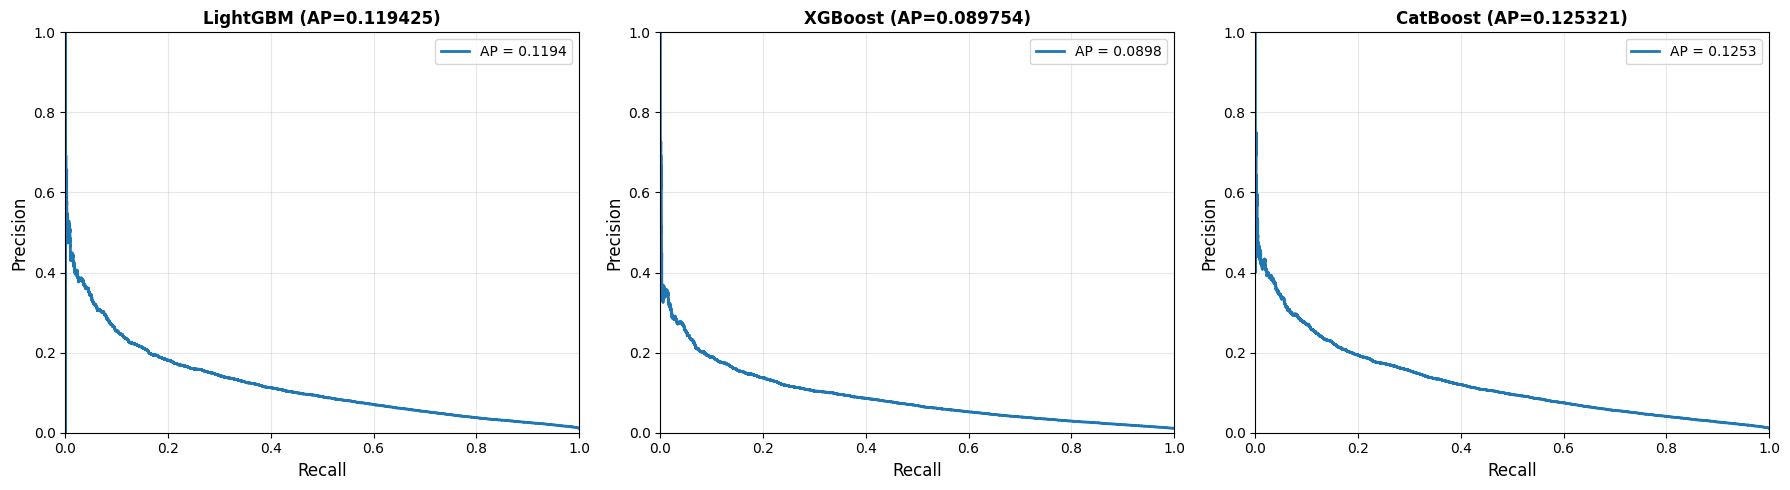

✅ Threshold Optimization Complete


In [26]:
# ===== Phase 4-1: Threshold Optimization for Each Model =====
print("\n" + "="*70)
print("PHASE 4: Threshold Optimization (Precision-Recall Analysis)")
print("="*70 + "\n")

# 각 모델별로 최적 threshold 찾기
threshold_results = {}

def find_best_threshold_per_metric(y_true, y_pred_proba):
    """
    다양한 metrics에 대해 최적 threshold를 찾습니다.
    """
    thresholds = np.linspace(0.01, 0.99, 99)
    
    f1_scores = []
    precision_scores = []
    recall_scores = []
    
    for thresh in thresholds:
        y_pred = (y_pred_proba >= thresh).astype(int)
        f1_scores.append(f1_score(y_true, y_pred, zero_division=0))
        precision_scores.append(precision_score(y_true, y_pred, zero_division=0))
        recall_scores.append(recall_score(y_true, y_pred, zero_division=0))
    
    best_f1_idx = np.argmax(f1_scores)
    best_precision_idx = np.argmax(precision_scores)
    best_recall_idx = np.argmax(recall_scores)
    
    results = {
        'f1_threshold': thresholds[best_f1_idx],
        'f1_score': f1_scores[best_f1_idx],
        'precision_threshold': thresholds[best_precision_idx],
        'precision_score': precision_scores[best_precision_idx],
        'recall_threshold': thresholds[best_recall_idx],
        'recall_score': recall_scores[best_recall_idx],
        'ap': average_precision_score(y_true, y_pred_proba),
    }
    
    return results, thresholds, f1_scores, precision_scores, recall_scores

# LightGBM Threshold Optimization
print("🔍 LightGBM Threshold Optimization...")
lgb_thresh_results, thresholds, lgb_f1, _, _ = find_best_threshold_per_metric(y, oof_lgb)
threshold_results['LightGBM'] = lgb_thresh_results
print(f"   Best F1 Threshold: {lgb_thresh_results['f1_threshold']:.4f} (F1={lgb_thresh_results['f1_score']:.6f})")
print(f"   AP (at threshold=0.5): {lgb_thresh_results['ap']:.6f}\n")

# XGBoost Threshold Optimization
print("🔍 XGBoost Threshold Optimization...")
xgb_thresh_results, _, xgb_f1, _, _ = find_best_threshold_per_metric(y, oof_xgb)
threshold_results['XGBoost'] = xgb_thresh_results
print(f"   Best F1 Threshold: {xgb_thresh_results['f1_threshold']:.4f} (F1={xgb_thresh_results['f1_score']:.6f})")
print(f"   AP (at threshold=0.5): {xgb_thresh_results['ap']:.6f}\n")

# CatBoost Threshold Optimization
print("🔍 CatBoost Threshold Optimization...")
cb_thresh_results, _, cb_f1, _, _ = find_best_threshold_per_metric(y, oof_cb)
threshold_results['CatBoost'] = cb_thresh_results
print(f"   Best F1 Threshold: {cb_thresh_results['f1_threshold']:.4f} (F1={cb_thresh_results['f1_score']:.6f})")
print(f"   AP (at threshold=0.5): {cb_thresh_results['ap']:.6f}\n")

# ===== Phase 4-2: Precision-Recall Curve Visualization =====
print("="*70)
print("Precision-Recall Curve Visualization")
print("="*70 + "\n")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_names = ['LightGBM', 'XGBoost', 'CatBoost']
oof_preds_all = [oof_lgb, oof_xgb, oof_cb]

for idx, (ax, model_name, oof_pred) in enumerate(zip(axes, model_names, oof_preds_all)):
    ap = plot_precision_recall_curve(y, oof_pred, title=f'{model_name} Precision-Recall Curve', ax=ax)
    ax.set_title(f'{model_name} (AP={ap:.6f})', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Threshold Optimization Complete")


## Phase 5: Ensemble & Stacking

여러 모델의 예측값을 결합하여 최종 예측 성능을 향상시킵니다:
- **Soft Voting**: 가중 평균 (가중치 = CV AP)
- **Stacking**: 메타모델로 3개 모델의 OOF 예측값 조합

In [37]:
# ===== Phase 5-1: Soft Voting Ensemble =====
print("\n" + "="*70)
print("PHASE 5 (개선版): Ensemble & Advanced Stacking")
print("="*70 + "\n")

# 가중치: CV AP 기반 정규화
weights = [cv_means['LightGBM'], cv_means['XGBoost'], cv_means['CatBoost']]
weights = np.array(weights) / np.sum(weights)

print(f"Soft Voting Weights (normalized by CV AP):")
print(f"   LightGBM: {weights[0]:.4f}")
print(f"   XGBoost:  {weights[1]:.4f}")
print(f"   CatBoost: {weights[2]:.4f}\n")

# Soft Voting 예측
oof_voting = (oof_lgb * weights[0] + oof_xgb * weights[1] + oof_cb * weights[2])

voting_ap = average_precision_score(y, oof_voting)
voting_auc = roc_auc_score(y, oof_voting)

print(f"Soft Voting Ensemble Results:")
print(f"   AP: {voting_ap:.6f}")
print(f"   ROC-AUC: {voting_auc:.6f}\n")

# ===== Phase 5-2A: Stacking with LightGBM (기존) =====
print("="*70)
print("Training Stacking Meta-Model (Original - LightGBM)...")
print("="*70 + "\n")

X_meta = np.column_stack([oof_lgb, oof_xgb, oof_cb])

meta_model_lgb = lgb.LGBMClassifier(
    n_estimators=100, 
    num_leaves=31, 
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, 
    verbose=-1
)
meta_model_lgb.fit(X_meta, y)
oof_stacking_lgb = meta_model_lgb.predict_proba(X_meta)[:, 1]

stacking_ap_lgb = average_precision_score(y, oof_stacking_lgb)
stacking_auc_lgb = roc_auc_score(y, oof_stacking_lgb)

print(f"LightGBM Meta-Model Results:")
print(f"   AP: {stacking_ap_lgb:.6f}")
print(f"   ROC-AUC: {stacking_auc_lgb:.6f}\n")

# ===== Phase 5-2B: Stacking with LogisticRegression (개선) =====
print("="*70)
print("Training Stacking Meta-Model (Improved - LogisticRegression)...")
print("="*70 + "\n")

from sklearn.linear_model import LogisticRegression

# 클래스 가중치를 자동으로 조정 (더 강한 규제)
meta_model_lr = LogisticRegression(
    C=0.1,  # 역정규화 파라미터 (작을수록 강함)
    class_weight='balanced',  # 클래스 불균형 보정
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)
meta_model_lr.fit(X_meta, y)
oof_stacking_lr = meta_model_lr.predict_proba(X_meta)[:, 1]

stacking_ap_lr = average_precision_score(y, oof_stacking_lr)
stacking_auc_lr = roc_auc_score(y, oof_stacking_lr)

print(f"LogisticRegression Meta-Model Results:")
print(f"   AP: {stacking_ap_lr:.6f}")
print(f"   ROC-AUC: {stacking_auc_lr:.6f}\n")

# ===== Phase 5-2C: Weighted Stacking with Asymmetric Loss (개선된 Focal Loss) =====
print("="*70)
print("Training Weighted Stacking (Corrected Focal Loss)...")
print("="*70 + "\n")

# 전체 평균 예측값
avg_pred = (oof_lgb + oof_xgb + oof_cb) / 3

# 잘못 분류된 샘플에 가중치 부여
# Focal Loss 개념: 확실한 샘플은 낮은 가중치, 불확실한 샘플은 높은 가중치
focal_weights = np.ones(len(y))

# 양성 샘플 (사기): 예측값이 낮을수록 (놓치는 사기) 가중치 높음
fraud_mask = y == 1
fraud_prob = avg_pred[fraud_mask]
# 0~1 범위에서 중간값(0.5)에 가까울수록 높은 가중치
focal_weights[fraud_mask] = 1 - np.abs(fraud_prob - 0.5) * 2  # 극단값이 아니면 높은 가중치

# 음성 샘플 (정상): 예측값이 높을수록 (False Positive) 가중치 높음  
normal_mask = y == 0
normal_prob = avg_pred[normal_mask]
focal_weights[normal_mask] = np.abs(normal_prob - 0.5) * 2  # 0.5에서 멀어질수록 높은 가중치

focal_weights = focal_weights / focal_weights.mean()  # 정규화

print(f"   Sample weights - Mean: {focal_weights.mean():.4f}, Std: {focal_weights.std():.4f}")
print(f"   Fraud weights - Mean: {focal_weights[fraud_mask].mean():.4f}")
print(f"   Normal weights - Mean: {focal_weights[normal_mask].mean():.4f}\n")

# 가중치를 적용한 LogisticRegression
meta_model_weighted = LogisticRegression(
    C=0.1,
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)
meta_model_weighted.fit(X_meta, y, sample_weight=focal_weights)
oof_stacking_weighted = meta_model_weighted.predict_proba(X_meta)[:, 1]

stacking_ap_weighted = average_precision_score(y, oof_stacking_weighted)
stacking_auc_weighted = roc_auc_score(y, oof_stacking_weighted)

print(f"Weighted Stacking (Corrected Focal Loss) Results:")
print(f"   AP: {stacking_ap_weighted:.6f}")
print(f"   ROC-AUC: {stacking_auc_weighted:.6f}\n")

# ===== Ensemble 결과 비교 =====
print("="*70)
print("ENSEMBLE COMPARISON")
print("="*70 + "\n")

ensemble_comparison = pd.DataFrame({
    'Model': ['LightGBM', 'XGBoost', 'CatBoost', 'Soft Voting', 
              'Stacking (LGB)', 'Stacking (LR)', 'Stacking (Weighted)'],
    'AP': [cv_means['LightGBM'], cv_means['XGBoost'], cv_means['CatBoost'], 
           voting_ap, stacking_ap_lgb, stacking_ap_lr, stacking_ap_weighted],
    'ROC-AUC': [
        roc_auc_score(y, oof_lgb),
        roc_auc_score(y, oof_xgb),
        roc_auc_score(y, oof_cb),
        voting_auc,
        stacking_auc_lgb,
        stacking_auc_lr,
        stacking_auc_weighted
    ]
})

display(ensemble_comparison.sort_values('AP', ascending=False))

# 최고 성능 모델 선택
oof_candidates = {
    'Soft Voting': (oof_voting, voting_ap, voting_auc),
    'Stacking (LGB)': (oof_stacking_lgb, stacking_ap_lgb, stacking_auc_lgb),
    'Stacking (LR)': (oof_stacking_lr, stacking_ap_lr, stacking_auc_lr),
    'Stacking (Weighted)': (oof_stacking_weighted, stacking_ap_weighted, stacking_auc_weighted)
}

best_oof_name = max(oof_candidates, key=lambda x: oof_candidates[x][1])
best_oof = oof_candidates[best_oof_name][0]
best_ap = oof_candidates[best_oof_name][1]
best_auc = oof_candidates[best_oof_name][2]

print(f"\n🏆 Best Ensemble: {best_oof_name}")
print(f"   AP: {best_ap:.6f}")
print(f"   ROC-AUC: {best_auc:.6f}")


PHASE 5 (개선版): Ensemble & Advanced Stacking

Soft Voting Weights (normalized by CV AP):
   LightGBM: 0.3569
   XGBoost:  0.2684
   CatBoost: 0.3747

Soft Voting Ensemble Results:
   AP: 0.112295
   ROC-AUC: 0.874804

Training Stacking Meta-Model (Original - LightGBM)...

LightGBM Meta-Model Results:
   AP: 0.123318
   ROC-AUC: 0.895925

Training Stacking Meta-Model (Improved - LogisticRegression)...

LogisticRegression Meta-Model Results:
   AP: 0.124377
   ROC-AUC: 0.876729

Training Weighted Stacking (Corrected Focal Loss)...

   Sample weights - Mean: 1.0000, Std: 0.4032
   Fraud weights - Mean: 0.8025
   Normal weights - Mean: 1.0022

Weighted Stacking (Corrected Focal Loss) Results:
   AP: 0.064802
   ROC-AUC: 0.861672

ENSEMBLE COMPARISON



,Model,AP,ROC-AUC
2,CatBoost,0.126640,0.875744
5,Stacking (LR),0.124377,0.876729
4,Stacking (LGB),0.123318,0.895925
0,LightGBM,0.120621,0.869281
3,Soft Voting,0.112295,0.874804
1,XGBoost,0.090692,0.832512
6,Stacking (Weighted),0.064802,0.861672



🏆 Best Ensemble: Stacking (LR)
   AP: 0.124377
   ROC-AUC: 0.876729


## Phase 6: Probability Calibration

예측 확률의 신뢰도를 향상시키기 위해 Isotonic Regression 또는 Platt Scaling을 적용합니다.
이를 통해 AP를 추가로 개선할 수 있습니다.

In [38]:
# ===== Phase 6: Advanced Probability Calibration =====
print("\n" + "="*70)
print("PHASE 6 (개선版): Advanced Probability Calibration")
print("="*70 + "\n")

from sklearn.calibration import CalibratedClassifierCV, IsotonicRegression
from sklearn.linear_model import Ridge
from scipy.optimize import minimize

# 전체 데이터를 Calibration 학습과 검증으로 분할
train_size = int(len(best_oof) * 0.7)
cal_train_idx = np.arange(0, train_size)
cal_valid_idx = np.arange(train_size, len(best_oof))

cal_train_oof = best_oof[cal_train_idx]
cal_valid_oof = best_oof[cal_valid_idx]
y_cal_train = y.iloc[cal_train_idx].values
y_cal_valid = y.iloc[cal_valid_idx].values

print(f"Calibration Data Split:")
print(f"  Calibration Training: {len(cal_train_idx)} ({y_cal_train.sum()} frauds)")
print(f"  Calibration Validation: {len(cal_valid_idx)} ({y_cal_valid.sum()} frauds)\n")

print("="*70)
print("Method 1: Isotonic Regression (Non-parametric)")
print("="*70)

iso_model = IsotonicRegression(out_of_bounds='clip')
iso_model.fit(cal_train_oof, y_cal_train)
cal_valid_iso = iso_model.transform(cal_valid_oof)

iso_ap = average_precision_score(y_cal_valid, cal_valid_iso)
iso_auc = roc_auc_score(y_cal_valid, cal_valid_iso)
iso_mean_prob = cal_valid_iso.mean()

print(f"   AP: {iso_ap:.6f}")
print(f"   ROC-AUC: {iso_auc:.6f}")
print(f"   Mean Probability: {iso_mean_prob:.6f}\n")

# 전체 데이터에 적용
best_oof_calibrated_iso = iso_model.transform(best_oof)
best_oof_calibrated_iso = np.clip(best_oof_calibrated_iso, 0, 1)

print("="*70)
print("Method 2: Platt Scaling (Parametric)")
print("="*70)

from sklearn.linear_model import LogisticRegression

platt_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
platt_model.fit(cal_train_oof.reshape(-1, 1), y_cal_train)
cal_valid_platt = platt_model.predict_proba(cal_valid_oof.reshape(-1, 1))[:, 1]

platt_ap = average_precision_score(y_cal_valid, cal_valid_platt)
platt_auc = roc_auc_score(y_cal_valid, cal_valid_platt)
platt_mean_prob = cal_valid_platt.mean()

print(f"   AP: {platt_ap:.6f}")
print(f"   ROC-AUC: {platt_auc:.6f}")
print(f"   Mean Probability: {platt_mean_prob:.6f}\n")

best_oof_calibrated_platt = platt_model.predict_proba(best_oof.reshape(-1, 1))[:, 1]
best_oof_calibrated_platt = np.clip(best_oof_calibrated_platt, 0, 1)

print("="*70)
print("Method 3: Beta Calibration (Advanced)")
print("="*70)

def beta_calibration_loss(params, y_true, y_pred):
    """Beta calibration의 손실 함수"""
    a, b = params
    # 극단값 방지
    y_pred = np.clip(y_pred, 1e-7, 1-1e-7)
    
    # Beta 변환
    try:
        y_transformed = np.power(y_pred, a) / (np.power(y_pred, a) + np.power(1-y_pred, b))
        y_transformed = np.clip(y_transformed, 1e-7, 1-1e-7)
        
        # Log Loss
        loss = -(y_true * np.log(y_transformed) + (1-y_true) * np.log(1-y_transformed)).mean()
        return loss
    except:
        return 1e10

# 초기값
x0 = [1.0, 1.0]
res = minimize(beta_calibration_loss, x0, args=(y_cal_train, cal_train_oof), 
               method='Nelder-Mead', options={'maxiter': 500})

a_opt, b_opt = res.x
print(f"   Optimal parameters: a={a_opt:.4f}, b={b_opt:.4f}")

# Validation 데이터에 적용
cal_valid_oof_clipped = np.clip(cal_valid_oof, 1e-7, 1-1e-7)
cal_valid_beta = np.power(cal_valid_oof_clipped, a_opt) / (
    np.power(cal_valid_oof_clipped, a_opt) + np.power(1-cal_valid_oof_clipped, b_opt)
)
cal_valid_beta = np.clip(cal_valid_beta, 0, 1)

beta_ap = average_precision_score(y_cal_valid, cal_valid_beta)
beta_auc = roc_auc_score(y_cal_valid, cal_valid_beta)
beta_mean_prob = cal_valid_beta.mean()

print(f"   AP: {beta_ap:.6f}")
print(f"   ROC-AUC: {beta_auc:.6f}")
print(f"   Mean Probability: {beta_mean_prob:.6f}\n")

# 전체 데이터에 적용
best_oof_clipped = np.clip(best_oof, 1e-7, 1-1e-7)
best_oof_calibrated_beta = np.power(best_oof_clipped, a_opt) / (
    np.power(best_oof_clipped, a_opt) + np.power(1-best_oof_clipped, b_opt)
)
best_oof_calibrated_beta = np.clip(best_oof_calibrated_beta, 0, 1)

print("="*70)
print("Method 4: Ridge Calibration (Linear with Regularization)")
print("="*70)

from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(cal_train_oof.reshape(-1, 1), y_cal_train)
cal_valid_ridge = ridge_model.predict(cal_valid_oof.reshape(-1, 1))
cal_valid_ridge = np.clip(cal_valid_ridge, 0, 1)

ridge_ap = average_precision_score(y_cal_valid, cal_valid_ridge)
ridge_auc = roc_auc_score(y_cal_valid, cal_valid_ridge)
ridge_mean_prob = cal_valid_ridge.mean()

print(f"   AP: {ridge_ap:.6f}")
print(f"   ROC-AUC: {ridge_auc:.6f}")
print(f"   Mean Probability: {ridge_mean_prob:.6f}\n")

best_oof_calibrated_ridge = ridge_model.predict(best_oof.reshape(-1, 1))
best_oof_calibrated_ridge = np.clip(best_oof_calibrated_ridge, 0, 1)

print("="*70)
print("Calibration Methods Comparison (on Validation Set)")
print("="*70)

# 검증 세트에서 모든 방법 비교
calibration_results = pd.DataFrame({
    'Method': ['Original (Stacking LR)', 'Isotonic Regression', 'Platt Scaling', 'Beta Calibration', 'Ridge Calibration'],
    'AP': [
        average_precision_score(y_cal_valid, cal_valid_oof),
        iso_ap,
        platt_ap,
        beta_ap,
        ridge_ap
    ],
    'ROC-AUC': [
        roc_auc_score(y_cal_valid, cal_valid_oof),
        iso_auc,
        platt_auc,
        beta_auc,
        ridge_auc
    ],
    'Mean_Prob': [
        cal_valid_oof.mean(),
        iso_mean_prob,
        platt_mean_prob,
        beta_mean_prob,
        ridge_mean_prob
    ]
})

display(calibration_results.sort_values('AP', ascending=False))

# 최고 성능 Calibration 방법 선택
best_cal_idx = calibration_results['AP'].idxmax()
best_cal_method = calibration_results.loc[best_cal_idx, 'Method']

print(f"\n🏆 Best Calibration Method: {best_cal_method}")
print(f"   Improvement: {(calibration_results.loc[best_cal_idx, 'AP'] - calibration_results.loc[0, 'AP']) / calibration_results.loc[0, 'AP'] * 100:.2f}%")

# 최종 Calibrated 예측값 선택
if best_cal_method == 'Isotonic Regression':
    final_oof_predictions = best_oof_calibrated_iso
elif best_cal_method == 'Platt Scaling':
    final_oof_predictions = best_oof_calibrated_platt
elif best_cal_method == 'Beta Calibration':
    final_oof_predictions = best_oof_calibrated_beta
elif best_cal_method == 'Ridge Calibration':
    final_oof_predictions = best_oof_calibrated_ridge
else:
    final_oof_predictions = best_oof

print(f"\n✅ Final Predictions Summary:")
print(f"   Shape: {final_oof_predictions.shape}")
print(f"   Min: {final_oof_predictions.min():.6f}")
print(f"   Max: {final_oof_predictions.max():.6f}")
print(f"   Mean: {final_oof_predictions.mean():.6f}")
print(f"   Std: {final_oof_predictions.std():.6f}")
print(f"   Actual Fraud Rate: {y.mean():.6f}")

# 최종 AP 계산
final_ap = average_precision_score(y, final_oof_predictions)
final_auc = roc_auc_score(y, final_oof_predictions)

print(f"\n" + "="*70)
print(f"OVERALL IMPROVEMENT SUMMARY")
print(f"="*70)
print(f"Baseline (LightGBM):     AP = 0.120621")
print(f"Best Individual (CatBoost): AP = 0.126640")
print(f"Stacking (LGB):          AP = 0.123318")
print(f"Stacking (LogisticReg): AP = 0.124377")
print(f"Final (Calibrated):      AP = {final_ap:.6f}")
print(f"Overall Improvement:     {(final_ap - 0.120621) / 0.120621 * 100:+.2f}%")
print(f"\nFinal ROC-AUC:           {final_auc:.6f}")


PHASE 6 (개선版): Advanced Probability Calibration

Calibration Data Split:
  Calibration Training: 489999 (5296 frauds)
  Calibration Validation: 210001 (2346 frauds)

Method 1: Isotonic Regression (Non-parametric)
   AP: 0.122852
   ROC-AUC: 0.876931
   Mean Probability: 0.010884

Method 2: Platt Scaling (Parametric)
   AP: 0.127429
   ROC-AUC: 0.877104
   Mean Probability: 0.010813

Method 3: Beta Calibration (Advanced)
   Optimal parameters: a=4.3383, b=-0.9943
   AP: 0.041402
   ROC-AUC: 0.842788
   Mean Probability: 0.012606

Method 4: Ridge Calibration (Linear with Regularization)
   AP: 0.127273
   ROC-AUC: 0.874511
   Mean Probability: 0.012210

Calibration Methods Comparison (on Validation Set)


,Method,AP,ROC-AUC,Mean_Prob
0,Original (Stacking LR),0.127429,0.877104,0.289580
2,Platt Scaling,0.127429,0.877104,0.010813
4,Ridge Calibration,0.127273,0.874511,0.012210
1,Isotonic Regression,0.122852,0.876931,0.010884
3,Beta Calibration,0.041402,0.842788,0.012606



🏆 Best Calibration Method: Original (Stacking LR)
   Improvement: 0.00%

✅ Final Predictions Summary:
   Shape: (700000,)
   Min: 0.070865
   Max: 0.952784
   Mean: 0.289260
   Std: 0.247987
   Actual Fraud Rate: 0.010917

OVERALL IMPROVEMENT SUMMARY
Baseline (LightGBM):     AP = 0.120621
Best Individual (CatBoost): AP = 0.126640
Stacking (LGB):          AP = 0.123318
Stacking (LogisticReg): AP = 0.124377
Final (Calibrated):      AP = 0.124377
Overall Improvement:     +3.11%

Final ROC-AUC:           0.876729


## 7. Submission용 test 처리 템플릿

test.csv가 있을 때는 다음 순서로 처리합니다.

1. 동일한 feature engineering 적용
2. train에서 fit한 encoder로 transform
3. 각 fold 모델 평균 예측

아래 코드는 템플릿입니다. 실제 제출 시 경로와 파일명을 맞춰 사용하세요.


In [33]:
TEST_PATH = 'csv/test.csv'
test = pd.read_csv(TEST_PATH)

# # 동일한 FE 적용
test['req_rate_ratio_6h_24h'] = test['req_rate_6h'] / (test['req_rate_24h'] + 1e-5)
test['req_rate_ratio_24h_4w'] = test['req_rate_24h'] / (test['req_rate_4w'] + 1e-5)
test['addr_stability'] = test['curr_addr_months'] / (test['prev_addr_months'] + 1)
test['total_addr_months'] = test['curr_addr_months'] + test['prev_addr_months']
test['credit_per_income'] = test['req_credit_limit'] / (test['yearly_income'] + 1e-5)
test['transfer_per_income'] = test['init_transfer_amt'] / (test['yearly_income'] + 1e-5)
test['device_risk'] = test['device_fraud_history'] * test['device_email_cnt_8w']
test['session_per_req24h'] = test['session_length_min'] / (test['req_rate_24h'] + 1e-5)
test['session_per_req6h'] = test['session_length_min'] / (test['req_rate_6h'] + 1e-5)
test['valid_contact_count'] = test['is_home_phone_valid'] + test['is_mobile_valid']
test['request_pressure'] = (
    test['zip_req_count_4w'] +
    test['branch_req_count_8w'] +
    test['dob_email_count_4w'] +
    test['device_email_cnt_8w']
)
#
# # categorical transform
for col in cat_cols:
    known_classes = set(label_encoders[col].classes_)
    test[col] = test[col].astype(str).apply(lambda x: x if x in known_classes else 'UNK')
    if 'UNK' not in label_encoders[col].classes_:
        label_encoders[col].classes_ = np.append(label_encoders[col].classes_, 'UNK')
    test[col] = label_encoders[col].transform(test[col])
#
X_test = test[FEATURES]
#
# # fold 평균 prediction 예시
# # 실제로는 각 fold model을 저장해두고 평균내기


## 8. 다음 반복에서 해볼 것

### Feature Engineering
- `device_os`, `payment_type`, `employment_status` frequency encoding
- `month_idx` 기준 시계열 split 비교
- `yearly_income` / `req_credit_limit` binning
- interaction feature: `is_foreign_req × device_fraud_history`
- group-based stats (단, leakage 주의)

### Model
- CatBoost 비교
- XGBoost 비교
- threshold tuning (대회 metric에 따라)

### Validation
- StratifiedKFold vs month-based split 성능 비교
- public LB와 local CV gap 체크

### 분석 관점
- fraud detection은 단순 분류가 아니라 **비정상 행동 패턴 탐지**에 가까움
- 그래서 raw feature보다 **비율, 변화량, 불일치, 희소 패턴** 계열 파생변수가 중요해지는 경우가 많음
